In [1]:
import geopandas as gpd
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import Point
from shapely.geometry.polygon import Polygon
from matplotlib.colors import ListedColormap

In [2]:
divipola_df=pd.read_csv('/content/drive/MyDrive/eco2026/Divipola_renamed.csv')
divipola_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1122 entries, 0 to 1121
Data columns (total 7 columns):
 #   Column                                           Non-Null Count  Dtype 
---  ------                                           --------------  ----- 
 0   cod_departamento                                 1122 non-null   int64 
 1   nombre_depto                                     1122 non-null   object
 2   cod_municipio                                    1122 non-null   int64 
 3   nombre_mpio                                      1122 non-null   object
 4   Tipo: Municipio / Isla / Área no municipalizada  1122 non-null   object
 5   longitud                                         1122 non-null   object
 6   Latitud                                          1122 non-null   object
dtypes: int64(2), object(5)
memory usage: 61.5+ KB


# Conversion y homogenizacion de datos
Normalizacion de nombres de columnas y tipos de datos

In [3]:
agro_df=pd.read_csv('/content/drive/MyDrive/eco2026/EvaluacionAgro_EVA_2026.csv')
agro_df = agro_df.rename(columns={
    'CÓD. \nDEP.': 'cod_departamento',
    'CÓD. MUN.': 'cod_mcpio',
    'GRUPO \nDE CULTIVO': 'grupo_cultivo',
    'SUBGRUPO \nDE CULTIVO': 'subgrupo_cultivo',
    'NOMBRE \nCIENTIFICO': 'nombre_cientifico',
    'CICLO DE CULTIVO': 'ciclo_cultivo',
     'Área Sembrada\n(ha)': 'area_sembrada_ha',
    'Área Cosechada\n(ha)': 'area_cosechada_ha',
    'Rendimiento\n(t/ha)': 'rendimiento_t_ha',
    'Producción\n(t)': 'produccion_t'
})
agro_df['cod_mcpio'] = agro_df['cod_mcpio'].str.replace(',', '', regex=False)
agro_df['cod_mcpio'] = pd.to_numeric(agro_df['cod_mcpio'], errors='coerce').astype('Int64')
agro_df['area_sembrada_ha'] = pd.to_numeric(agro_df['area_sembrada_ha'], errors='coerce').astype('Int64')
agro_df['area_cosechada_ha'] = pd.to_numeric(agro_df['area_cosechada_ha'], errors='coerce').astype('Int64')
agro_df['produccion_t']=pd.to_numeric(agro_df['produccion_t'], errors='coerce').astype('Int64')
agro_df['rendimiento_t_ha']=pd.to_numeric(agro_df['rendimiento_t_ha'], errors='coerce').astype('float64')

In [4]:

agro_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206068 entries, 0 to 206067
Data columns (total 17 columns):
 #   Column                                         Non-Null Count   Dtype  
---  ------                                         --------------   -----  
 0   cod_departamento                               206068 non-null  int64  
 1   DEPARTAMENTO                                   206068 non-null  object 
 2   cod_mcpio                                      206068 non-null  Int64  
 3   MUNICIPIO                                      206067 non-null  object 
 4   grupo_cultivo                                  206068 non-null  object 
 5   subgrupo_cultivo                               206068 non-null  object 
 6   CULTIVO                                        206068 non-null  object 
 7   DESAGREGACIÓN REGIONAL Y/O SISTEMA PRODUCTIVO  206068 non-null  object 
 8   AÑO                                            206068 non-null  object 
 9   PERIODO                              

In [5]:
agro_df.head()

,cod_departamento,DEPARTAMENTO,cod_mcpio,MUNICIPIO,grupo_cultivo,subgrupo_cultivo,CULTIVO,DESAGREGACIÓN REGIONAL Y/O SISTEMA PRODUCTIVO,AÑO,PERIODO,area_sembrada_ha,area_cosechada_ha,produccion_t,rendimiento_t_ha,ESTADO FISICO PRODUCCION,nombre_cientifico,ciclo_cultivo
0,15,BOYACA,15114,BUSBANZA,HORTALIZAS,ACELGA,ACELGA,ACELGA,"2,006",2006B,2,1,1,1.00,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
1,25,CUNDINAMARCA,25754,SOACHA,HORTALIZAS,ACELGA,ACELGA,ACELGA,"2,006",2006B,82,80,<NA>,18.00,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
2,25,CUNDINAMARCA,25214,COTA,HORTALIZAS,ACELGA,ACELGA,ACELGA,"2,006",2006B,2,2,26,17.33,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
3,54,NORTE DE SANTANDER,54405,LOS PATIOS,HORTALIZAS,ACELGA,ACELGA,ACELGA,"2,006",2006B,3,3,48,16.00,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
4,54,NORTE DE SANTANDER,54518,PAMPLONA,HORTALIZAS,ACELGA,ACELGA,ACELGA,"2,006",2006B,1,1,5,10.00,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO


## Validacion de existencia de municipios

Se valida que todos los municipios reportados en los cultivos, existe en la base maestra de la divipola.

In [6]:
missing_municipios = agro_df[~agro_df['cod_mcpio'].isin(divipola_df['cod_municipio'])]

unique_missing_municipios = missing_municipios['cod_mcpio'].unique()

if len(unique_missing_municipios) > 0:
    print(f"Se encontro {len(unique_missing_municipios)}  cod_mcpio en  agro_df que no esta en divipola_df:\n{unique_missing_municipios}")
else:
    print("todos los valores de  cod_mcpio values en agro_df estan presentes en divipola_df.")

todos los valores de  cod_mcpio values en agro_df estan presentes en divipola_df.


## Analisis de rendimiento de  cultivos
Analizaremos los 10 cultivos que tienen mayor rendimiento,  y los municipios donde presentan este comportamiento.

In [7]:
# Convert columns to numeric, handling commas and errors
agro_df['AÑO'] = agro_df['AÑO'].astype(str).str.replace(',', '', regex=False)
agro_df['AÑO'] = pd.to_numeric(agro_df['AÑO'], errors='coerce').astype('Int64')
agro_df['area_sembrada_ha'] = agro_df['area_sembrada_ha'].astype(str).str.replace(',', '', regex=False)
agro_df['area_sembrada_ha'] = pd.to_numeric(agro_df['area_sembrada_ha'], errors='coerce')
agro_df['area_cosechada_ha'] = agro_df['area_cosechada_ha'].astype(str).str.replace(',', '', regex=False)
agro_df['area_cosechada_ha'] = pd.to_numeric(agro_df['area_cosechada_ha'], errors='coerce')
agro_df['produccion_t'] = agro_df['produccion_t'].astype(str).str.replace(',', '', regex=False)
agro_df['produccion_t'] = pd.to_numeric(agro_df['produccion_t'], errors='coerce')

# Group by MUNICIPIO and CULTIVO and calculate the mean rendimiento_t_ha
yield_performance = agro_df.groupby(['MUNICIPIO', 'CULTIVO'])['rendimiento_t_ha'].mean().reset_index()

# Sort by rendimiento_t_ha in descending order and get the top 20
top_20_yield = yield_performance.sort_values(by='rendimiento_t_ha', ascending=False).head(20)

print("Top 20 municipalities and crops by yield performance:")
print(top_20_yield)


Top 20 municipalities and crops by yield performance:
                MUNICIPIO         CULTIVO  rendimiento_t_ha
3196            CHACHAGUI          TOMATE        197.066667
16160                SORA          TOMATE        172.455556
6532            GIRARDOTA          TOMATE        150.720000
14810  SAN MIGUEL DE SEMA          TOMATE        150.000000
13337           RISARALDA  CAÑA AZUCARERA        143.636667
1618      BELEN DE UMBRIA  CAÑA AZUCARERA        141.994000
6021             FREDONIA          TOMATE        137.448333
18854               YUMBO  CAÑA AZUCARERA        137.316667
18281               VIJES  CAÑA AZUCARERA        135.787500
768               ANSERMA  CAÑA AZUCARERA        133.943000
5036           EL CERRITO  CAÑA AZUCARERA        132.471667
2706           CANDELARIA  CAÑA AZUCARERA        131.799167
11283             PALMIRA  CAÑA AZUCARERA        131.413333
5621             ENVIGADO          TOMATE        131.180000
15335  SANTA ROSA DE OSOS          TOMATE     

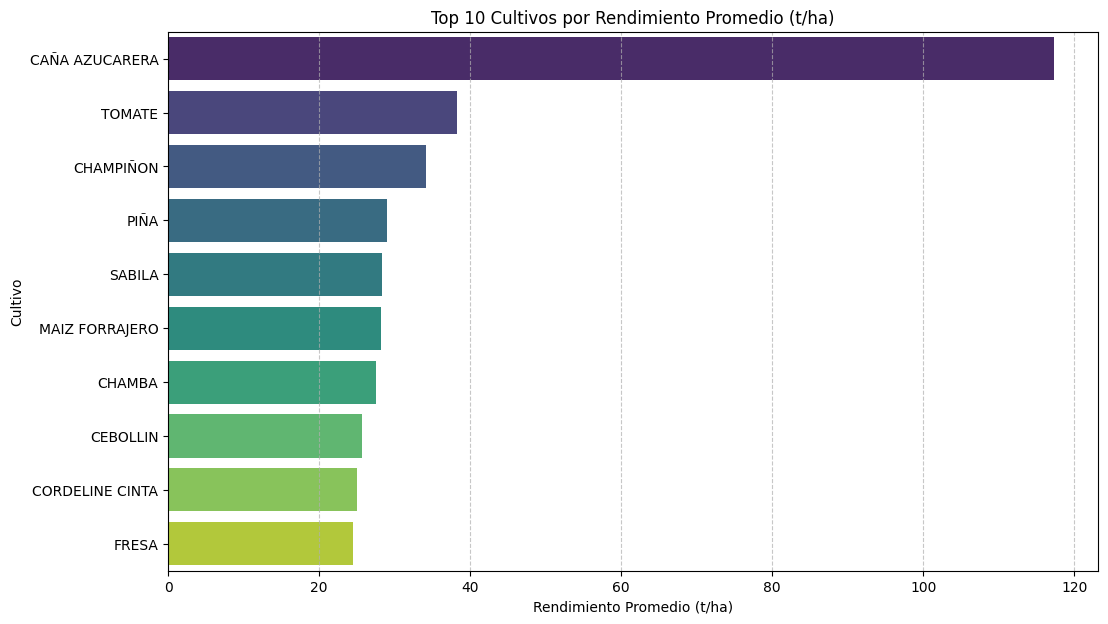

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular el rendimiento promedio por cultivo
rendimiento_por_cultivo = agro_df.groupby('CULTIVO')['rendimiento_t_ha'].mean().reset_index()

# Obtener los 10 cultivos con mayor rendimiento
top_10_cultivos = rendimiento_por_cultivo.nlargest(10, 'rendimiento_t_ha')

# Crear el gráfico de barras
plt.figure(figsize=(12, 7))
sns.barplot(x='rendimiento_t_ha', y='CULTIVO', data=top_10_cultivos, palette='viridis', hue='CULTIVO', legend=False)
plt.title('Top 10 Cultivos por Rendimiento Promedio (t/ha)')
plt.xlabel('Rendimiento Promedio (t/ha)')
plt.ylabel('Cultivo')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [8]:
unique_departments = agro_df['DEPARTAMENTO'].unique()
print("Departamentos con cultivos:")
for department in unique_departments:
    print(department)

Unique Departments with Crop Records:
BOYACA
CUNDINAMARCA
NORTE DE SANTANDER
SANTANDER
CAUCA
VALLE DEL CAUCA
CALDAS
PUTUMAYO
TOLIMA
NARIÑO
QUINDIO
ANTIOQUIA
CAQUETA
AMAZONAS
CHOCO
HUILA
ARAUCA
CASANARE
LA GUAJIRA
BOLIVAR
CESAR
META
RISARALDA
SUCRE
CORDOBA
VICHADA
MAGDALENA
GUAINIA
ATLANTICO
SAN ANDRES Y PROVIDENCIA
GUAVIARE
VAUPES


## Conteo de municipios con cultivos por departamento

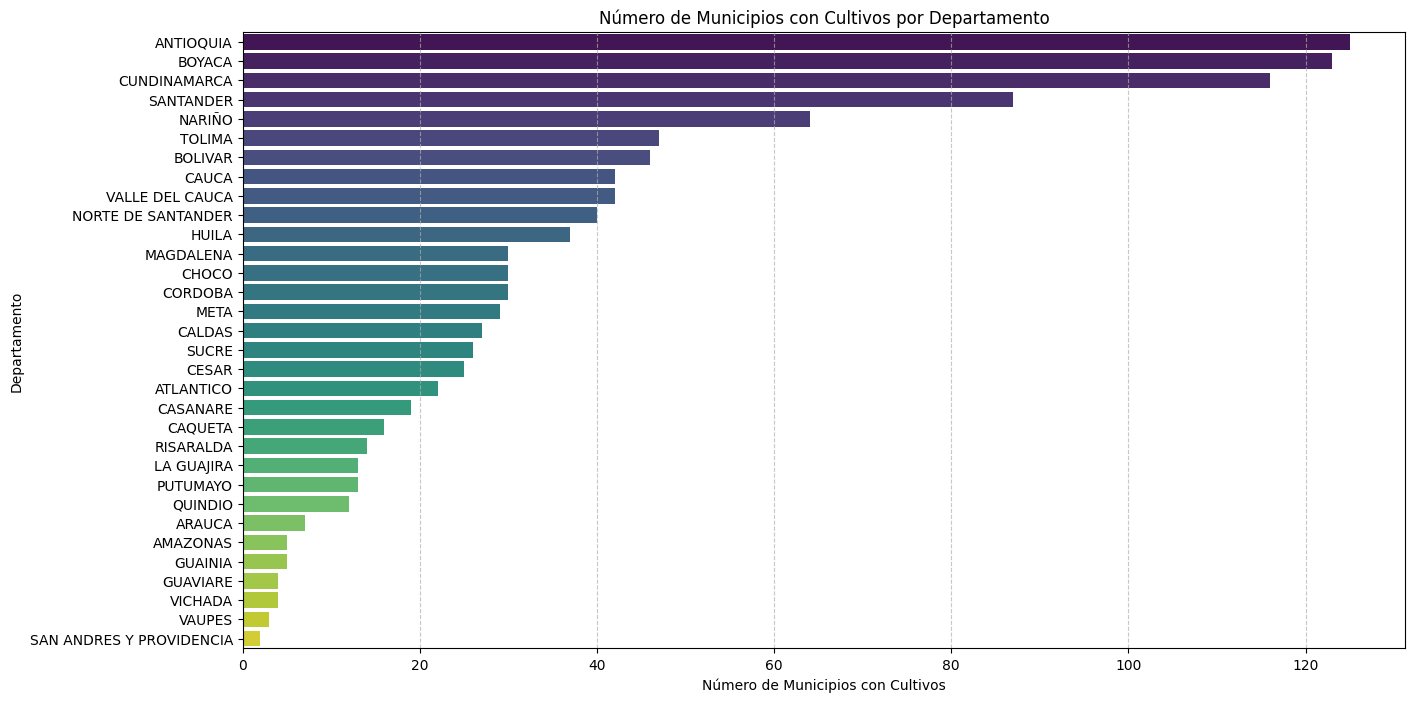

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupar por departamento y contar el número de municipios únicos con cultivos
municipios_por_departamento = agro_df.groupby('DEPARTAMENTO')['cod_mcpio'].nunique().reset_index()
municipios_por_departamento = municipios_por_departamento.sort_values(by='cod_mcpio', ascending=False)

# Crear el gráfico de barras
plt.figure(figsize=(15, 8))
sns.barplot(x='cod_mcpio', y='DEPARTAMENTO', data=municipios_por_departamento, palette='viridis', hue='DEPARTAMENTO', legend=False)
plt.title('Número de Municipios con Cultivos por Departamento')
plt.xlabel('Número de Municipios con Cultivos')
plt.ylabel('Departamento')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## Análisis del Grupo de Cultivo y Cultivo con Más Registros

In [13]:
# Contar la frecuencia de cada combinación de grupo_cultivo y CULTIVO
conteo_cultivos = agro_df.groupby(['grupo_cultivo', 'CULTIVO']).size().reset_index(name='cantidad_registros')

# Encontrar el grupo_cultivo y CULTIVO con la mayor cantidad de registros
cultivo_mas_frecuente = conteo_cultivos.loc[conteo_cultivos['cantidad_registros'].idxmax()]

print("El grupo de cultivo y cultivo con más registros es:")
print(cultivo_mas_frecuente)

top_grupo_cultivo = cultivo_mas_frecuente['grupo_cultivo']
top_cultivo = cultivo_mas_frecuente['CULTIVO']


El grupo de cultivo y cultivo con más registros es:
grupo_cultivo         CEREALES
CULTIVO                   MAIZ
cantidad_registros       24965
Name: 4, dtype: object


### Departamentos con más registros para el cultivo más frecuente

Departamentos con más registros para el grupo de cultivo 'CEREALES' y cultivo 'MAIZ':
      DEPARTAMENTO  cantidad_registros
0        ANTIOQUIA                2096
1           BOYACA                1976
2     CUNDINAMARCA                1901
3        SANTANDER                1767
4            HUILA                1715
5  VALLE DEL CAUCA                1490
6           NARIÑO                1213
7           TOLIMA                1209
8          BOLIVAR                1119
9          CORDOBA                 984


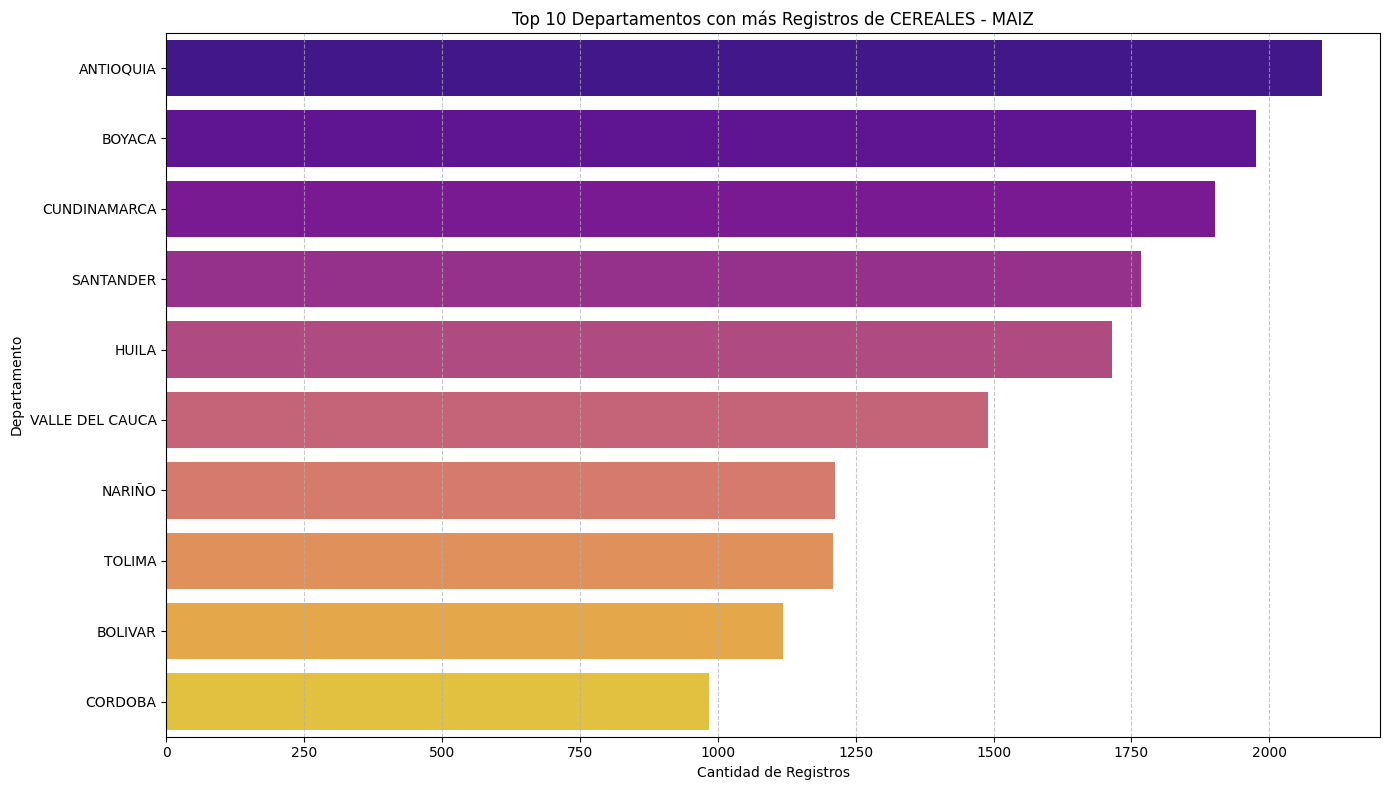

In [14]:
# Filtrar el DataFrame por el grupo_cultivo y CULTIVO más frecuente
df_top_cultivo = agro_df[(agro_df['grupo_cultivo'] == top_grupo_cultivo) & (agro_df['CULTIVO'] == top_cultivo)]

# Contar los registros por DEPARTAMENTO para este cultivo
registros_por_departamento_top_cultivo = df_top_cultivo['DEPARTAMENTO'].value_counts().reset_index()
registros_por_departamento_top_cultivo.columns = ['DEPARTAMENTO', 'cantidad_registros']

# Ordenar para visualización
registros_por_departamento_top_cultivo = registros_por_departamento_top_cultivo.sort_values(by='cantidad_registros', ascending=False)

print(f"Departamentos con más registros para el grupo de cultivo '{top_grupo_cultivo}' y cultivo '{top_cultivo}':")
print(registros_por_departamento_top_cultivo.head(10))

# Crear el gráfico de barras
plt.figure(figsize=(14, 8))
sns.barplot(x='cantidad_registros', y='DEPARTAMENTO', data=registros_por_departamento_top_cultivo.head(10), palette='plasma', hue='DEPARTAMENTO', legend=False)
plt.title(f'Top 10 Departamentos con más Registros de {top_grupo_cultivo} - {top_cultivo}')
plt.xlabel('Cantidad de Registros')
plt.ylabel('Departamento')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Análisis de Cultivos con Área Cosechada >= Área Sembrada

## Análisis de Cultivos con Mayor Área Sembrada y Peor Relación Cosecha/Siembra (Revisado)

Esta gráfica muestra los 10 cultivos con la mayor **Área Sembrada Total (ha)** que tienen una **relación de cosecha sobre siembra menor a 1**. Esto indica cultivos donde una parte significativa del área sembrada no fue cosechada, sugiriendo una posible ineficiencia.

*   El **eje X** representa la `Área Sembrada Total (ha)` en millones.
*   Para cada barra, se mostrarán **dos valores clave**:
    *   El **Área Sembrada Total** dentro o cerca de la barra.
    *   La **Relación Promedio Cosecha/Siembra** (`Ratio`) de forma explícita al final de cada barra.

Top 10 Cultivos con la mejor relación Área Cosechada / Área Sembrada (>= 1):
             CULTIVO  relacion_cosecha_sembrada
209             ÑAME                   1.009100
206             YUCA                   1.007300
170          PLATANO                   1.001477
62        CHONTADURO                   1.000597
123             LULO                   1.000507
23         ARRACACHA                   1.000414
196  TOMATE DE ARBOL                   1.000312
127          MALANGA                   1.000283
195           TOMATE                   1.000074
5           AGUACATE                   1.000034


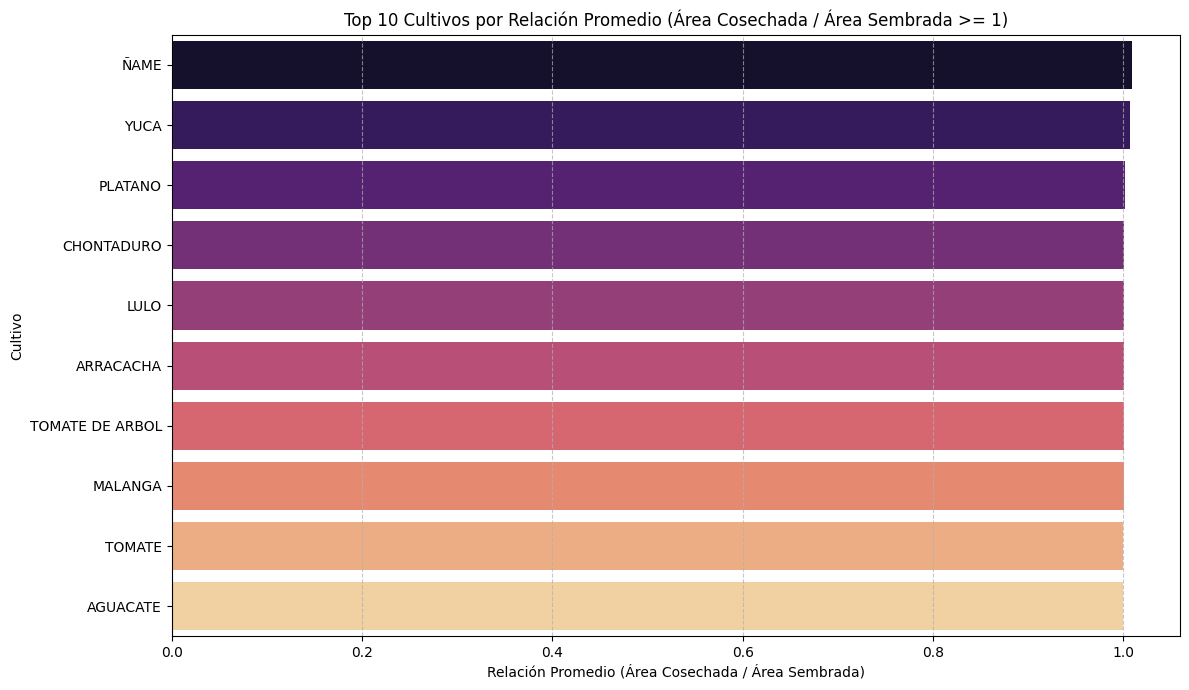

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar filas donde el área sembrada no es nula y no es cero, y el área cosechada no es nula
df_filtered = agro_df[agro_df['area_sembrada_ha'].notna() & (agro_df['area_sembrada_ha'] > 0) & agro_df['area_cosechada_ha'].notna()].copy()

# Calcular la relación de área cosechada sobre área sembrada
df_filtered['relacion_cosecha_sembrada'] = df_filtered['area_cosechada_ha'] / df_filtered['area_sembrada_ha']

# Filtrar los cultivos donde la relación es mayor o igual a 1
cultivos_eficientes = df_filtered[df_filtered['relacion_cosecha_sembrada'] >= 1]

# Calcular el promedio de la relación por CULTIVO
rendimiento_por_cultivo_eficiente = cultivos_eficientes.groupby('CULTIVO')['relacion_cosecha_sembrada'].mean().reset_index()

# Obtener los 10 cultivos con la mejor relación promedio
top_10_relacion_cultivos = rendimiento_por_cultivo_eficiente.nlargest(10, 'relacion_cosecha_sembrada')

print("Top 10 Cultivos con la mejor relación Área Cosechada / Área Sembrada (>= 1):")
print(top_10_relacion_cultivos)

# Crear el gráfico de barras
plt.figure(figsize=(12, 7))
sns.barplot(x='relacion_cosecha_sembrada', y='CULTIVO', data=top_10_relacion_cultivos, palette='magma', hue='CULTIVO', legend=False)
plt.title('Top 10 Cultivos por Relación Promedio (Área Cosechada / Área Sembrada >= 1)')
plt.xlabel('Relación Promedio (Área Cosechada / Área Sembrada)')
plt.ylabel('Cultivo')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Top 10 Cultivos con mayor Ineficiencia (Área Sembrada Total / Rendimiento Promedio):

           CULTIVO  total_area_sembrada_ha  promedio_rendimiento_t_ha  \
130           MAIZ               3918967.0                   1.929142   
40           CACAO                988912.0                   0.563722   
42            CAFE               1452197.0                   0.867533   
97          FRIJOL               1200827.0                   1.098538   
24           ARROZ               1461575.0                   3.666705   
176        PLATANO               1784541.0                   7.250218   
52   CAÑA PANELERA               1192603.0                   5.397958   
25          ARVEJA                316268.0                   1.520065   
48          CAUCHO                246528.0                   1.191346   
217           YUCA               1504382.0                  10.438488   

     inefficiency_score  
130        2.031456e+06  
40         1.754255e+06  
42         1.673939e+06  
97    

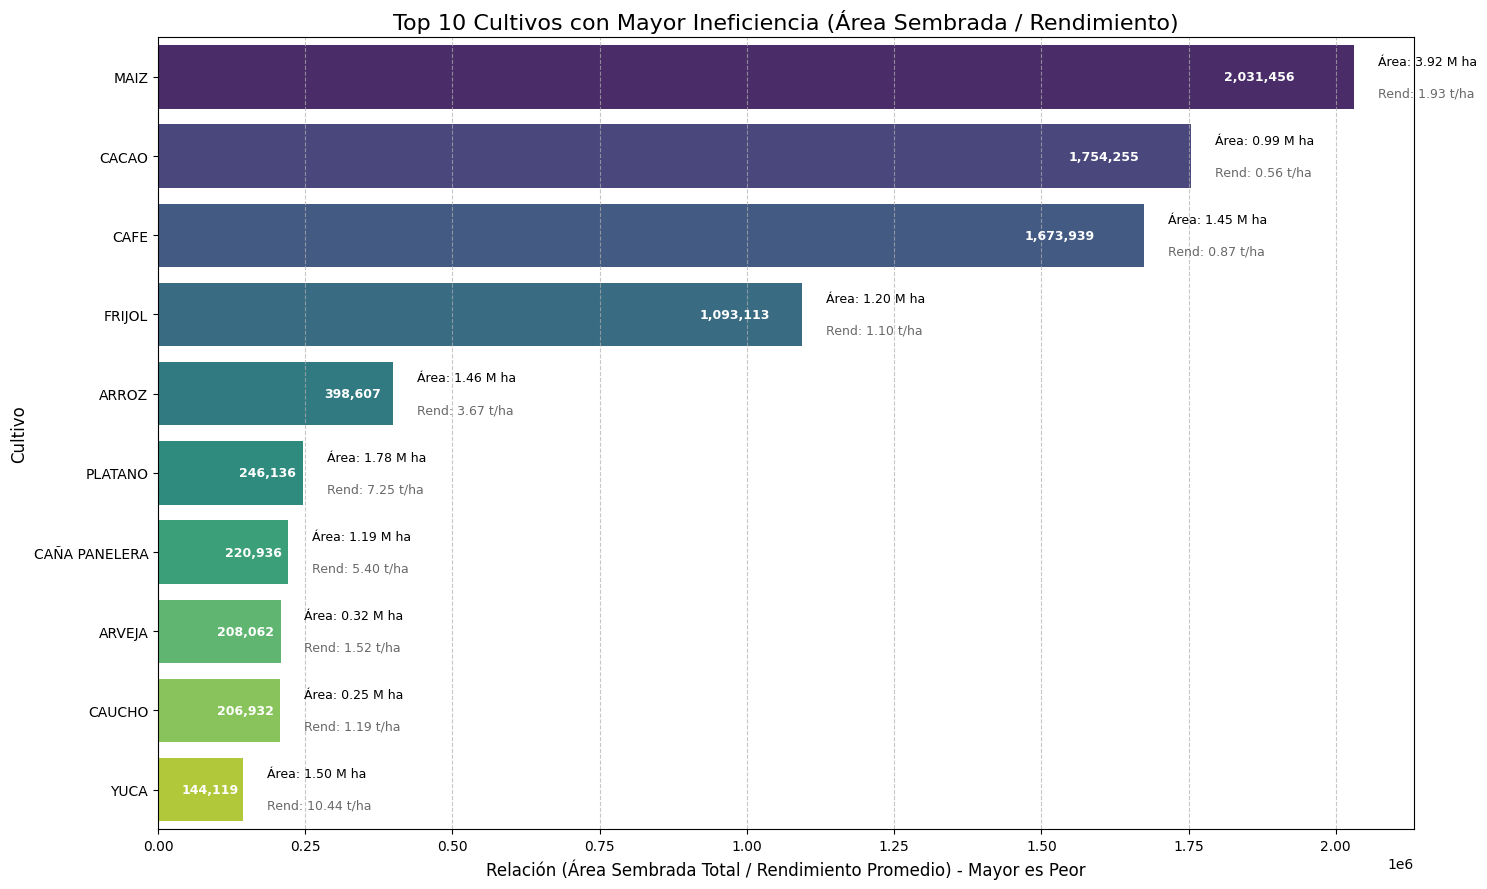

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupar por CULTIVO para obtener el área sembrada total y el rendimiento promedio
analisis_area_rendimiento = df_filtered.groupby('CULTIVO').agg(
    total_area_sembrada_ha=('area_sembrada_ha', 'sum'),
    promedio_rendimiento_t_ha=('rendimiento_t_ha', 'mean')
).reset_index()

# Filtrar cultivos con rendimiento promedio mayor a cero para evitar divisiones por cero o infinitos
analisis_area_rendimiento = analisis_area_rendimiento[analisis_area_rendimiento['promedio_rendimiento_t_ha'] > 0]

# Calcular la nueva métrica de 'ineficiencia': Área Sembrada Total / Rendimiento Promedio
# Un valor más alto indica que se necesita más área para la misma cantidad de rendimiento.
analisis_area_rendimiento['inefficiency_score'] = analisis_area_rendimiento['total_area_sembrada_ha'] / analisis_area_rendimiento['promedio_rendimiento_t_ha']

# Eliminar cualquier NaN que pueda haber surgido de cálculos
analisis_area_rendimiento = analisis_area_rendimiento.dropna(subset=['inefficiency_score'])

# Ordenar por 'inefficiency_score' en orden descendente para obtener los 10 más ineficientes
top_10_inefficient_crops = analisis_area_rendimiento.sort_values(
    by='inefficiency_score', ascending=False
).head(10)

print("Top 10 Cultivos con mayor Ineficiencia (Área Sembrada Total / Rendimiento Promedio):\n")
print(top_10_inefficient_crops)

# --- Graficar los resultados ---
plt.figure(figsize=(15, 9))

sns.barplot(x='inefficiency_score', y='CULTIVO', data=top_10_inefficient_crops, palette='viridis', hue='CULTIVO', legend=False)
plt.title('Top 10 Cultivos con Mayor Ineficiencia (Área Sembrada / Rendimiento)', fontsize=16)
plt.xlabel('Relación (Área Sembrada Total / Rendimiento Promedio) - Mayor es Peor', fontsize=12)
plt.ylabel('Cultivo', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Añadir etiquetas de texto para el score de ineficiencia (dentro de la barra),
# el área sembrada y el rendimiento promedio (fuera de la barra)
for plot_idx, (df_idx, row) in enumerate(top_10_inefficient_crops.iterrows()):
    # Posición en el eje X (final de la barra)
    x_bar_end = row['inefficiency_score']
    # Posición en el eje Y (índice de la barra en el gráfico)
    y_pos = plot_idx

    # Texto para el score de ineficiencia (dentro de la barra, ligeramente a la izquierda del final)
    plt.text(x_bar_end * 0.95, y_pos, f'{x_bar_end:,.0f}',
             color='white', ha='right', va='center', fontsize=9, weight='bold')

    # Offset para posicionar los textos fuera de la barra de manera consistente
    max_score = top_10_inefficient_crops['inefficiency_score'].max()
    offset_from_bar = max_score * 0.02

    # Texto del área sembrada (fuera de la barra, ligeramente por debajo del centro)
    plt.text(x_bar_end + offset_from_bar, y_pos - 0.2,
             f'Área: {row['total_area_sembrada_ha'] / 1_000_000:.2f} M ha',
             color='black', ha='left', va='center', fontsize=9)

    # Texto del rendimiento promedio (fuera de la barra, ligeramente por encima del centro)
    plt.text(x_bar_end + offset_from_bar, y_pos + 0.2,
             f'Rend: {row['promedio_rendimiento_t_ha']:.2f} t/ha',
             color='dimgray', ha='left', va='center', fontsize=9)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout() # Ajustar layout para prevenir solapamiento
plt.show()